In [42]:
#import libraries
import pandas as pd  
import matplotlib.pyplot as plt

In [43]:
#load the dataset
data = pd.read_csv('laptop.csv')

In [44]:
#see the data in one row
pd.set_option('display.max_columns',None)
pd.set_option('display.width',2000)
pd.set_option('display.max_colwidth',None)

print(data.head(10))

   Unnamed: 0.1  Unnamed: 0 Company   TypeName Inches                    ScreenResolution                         Cpu   Ram               Memory                           Gpu       OpSys  Weight        Price
0             0         0.0   Apple  Ultrabook   13.3  IPS Panel Retina Display 2560x1600        Intel Core i5 2.3GHz   8GB            128GB SSD  Intel Iris Plus Graphics 640       macOS  1.37kg   71378.6832
1             1         1.0   Apple  Ultrabook   13.3                            1440x900        Intel Core i5 1.8GHz   8GB  128GB Flash Storage        Intel HD Graphics 6000       macOS  1.34kg   47895.5232
2             2         2.0      HP   Notebook   15.6                   Full HD 1920x1080  Intel Core i5 7200U 2.5GHz   8GB            256GB SSD         Intel HD Graphics 620       No OS  1.86kg   30636.0000
3             3         3.0   Apple  Ultrabook   15.4  IPS Panel Retina Display 2880x1800        Intel Core i7 2.7GHz  16GB            512GB SSD            AMD Radeon P

In [45]:
#to see last 5 rows of data
print(data.tail(10))

      Unnamed: 0.1  Unnamed: 0 Company            TypeName Inches                            ScreenResolution                                   Cpu   Ram              Memory                      Gpu       OpSys  Weight       Price
1293          1293      1293.0  Lenovo            Notebook   15.6                 IPS Panel Full HD 1920x1080           Intel Core i7 6700HQ 2.6GHz   8GB             1TB HDD  Nvidia GeForce GTX 960M  Windows 10   2.6kg  47898.7200
1294          1294      1294.0      HP            Notebook   15.6                           Full HD 1920x1080             AMD A9-Series 9410 2.9GHz   6GB        1.0TB Hybrid       AMD Radeon R7 M440  Windows 10  2.04kg  29303.4672
1295          1295      1295.0    Dell            Notebook   15.6                                    1366x768            Intel Core i7 7500U 2.7GHz   8GB             1TB HDD       AMD Radeon R5 M430       Linux   2.3kg  42943.1472
1296          1296      1296.0      HP             Netbook   11.6           

In [46]:
#to see total number of rows and columns
print(data.shape)

(1303, 13)


In [47]:
#To show all column names
print(data.columns)

Index(['Unnamed: 0.1', 'Unnamed: 0', 'Company', 'TypeName', 'Inches', 'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight', 'Price'], dtype='object')


In [48]:
#delete the unnamed columns
data.drop(['Unnamed: 0.1', 'Unnamed: 0'], axis=1, inplace=True)

In [49]:
#To show data types and nulls
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1273 non-null   object 
 1   TypeName          1273 non-null   object 
 2   Inches            1273 non-null   object 
 3   ScreenResolution  1273 non-null   object 
 4   Cpu               1273 non-null   object 
 5   Ram               1273 non-null   object 
 6   Memory            1273 non-null   object 
 7   Gpu               1273 non-null   object 
 8   OpSys             1273 non-null   object 
 9   Weight            1273 non-null   object 
 10  Price             1273 non-null   float64
dtypes: float64(1), object(10)
memory usage: 112.1+ KB
None


In [50]:
#convert "Inches" column to numeric data type
data['Inches'] = pd.to_numeric(
    data['Inches'].str.replace('"', '', regex=False),
    errors='coerce'
)

In [51]:
#convert "Weight" column to numeric data type
data['Weight'] = data['Weight'].str.replace('kg', '', regex=False)
data['Weight'] = pd.to_numeric(data['Weight'], errors='coerce')

In [52]:
#To summarize statistics (categorical columns)
print(data.describe())

            Inches       Weight          Price
count  1272.000000  1272.000000    1273.000000
mean     15.130818     2.077618   59955.814073
std       1.954436     0.807808   37332.251005
min      10.100000     0.000200    9270.720000
25%      14.000000     1.500000   31914.720000
50%      15.600000     2.040000   52161.120000
75%      15.600000     2.320000   79333.387200
max      35.600000    11.100000  324954.720000


In [53]:
#Check missing values
print(data.isnull().sum())

Company             30
TypeName            30
Inches              31
ScreenResolution    30
Cpu                 30
Ram                 30
Memory              30
Gpu                 30
OpSys               30
Weight              31
Price               30
dtype: int64


In [54]:
#count rows with missing values
data.isnull().any(axis=1).sum()

np.int64(32)

In [55]:
#check rows with missing values
data[data.isnull().any(axis=1)]

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
115,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
148,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
190,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
208,Dell,Ultrabook,13.3,Full HD 1920x1080,Intel Core i7 8550U 1.8GHz,8GB,256GB SSD,Intel UHD Graphics 620,Windows 10,NaN,77202.72
209,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
267,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [56]:
#Drop rows with missing values and then check for missing values again
data=data.dropna()
print(data.isnull().sum())

Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64


In [57]:
#Check duplicate rows
print(data.duplicated().sum())

29


In [58]:
#To view duplicates
data[data.duplicated()]

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
1274,Asus,Notebook,15.6,1366x768,Intel Celeron Dual Core N3050 1.6GHz,4GB,500GB HDD,Intel HD Graphics,Windows 10,2.20,19660.3200
1275,Asus,Ultrabook,13.3,IPS Panel Full HD 1920x1080,Intel Core M 6Y30 0.9GHz,8GB,512GB SSD,Intel HD Graphics 515,Windows 10,1.20,38841.1200
1276,Dell,Notebook,15.6,1366x768,Intel Core i3 7100U 2.4GHz,6GB,1TB HDD,Intel HD Graphics 620,Windows 10,2.30,24455.5200
1277,Acer,Notebook,15.6,1366x768,Intel Celeron Dual Core N3060 1.6GHz,4GB,500GB HDD,Intel HD Graphics 400,Linux,2.40,15397.9200
1278,Dell,Notebook,15.6,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2GB,500GB HDD,Intel HD Graphics,Windows 10,2.20,20193.1200
1279,Lenovo,Notebook,15.6,IPS Panel Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,8GB,1TB HDD,Nvidia GeForce GTX 960M,Windows 10,2.60,47898.7200
1280,HP,Notebook,15.6,Full HD 1920x1080,AMD A9-Series 9410 2.9GHz,6GB,1.0TB Hybrid,AMD Radeon R7 M440,Windows 10,2.04,29303.4672
1281,Dell,Notebook,15.6,1366x768,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,AMD Radeon R5 M430,Linux,2.30,42943.1472
1282,HP,Netbook,11.6,1366x768,Intel Celeron Dual Core N3060 1.6GHz,2GB,32GB Flash Storage,Intel HD Graphics 400,Windows 10,1.17,11135.5200
1283,Asus,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,4GB,500GB HDD,Nvidia GeForce 920M,Windows 10,2.20,38378.6496


In [59]:
#Remove duplicates and then check it again
data=data.drop_duplicates()
print(data.duplicated().sum())

0


In [60]:
#Check unique values
for col in data.columns:
    print(col,data[col].nunique())

Company 19
TypeName 6
Inches 24
ScreenResolution 40
Cpu 118
Ram 10
Memory 40
Gpu 110
OpSys 9
Weight 180
Price 776


In [61]:
#Check correlation between numeric features
corr=data.corr(numeric_only=True)
print(corr)

          Inches    Weight     Price
Inches  1.000000  0.491223  0.042837
Weight  0.491223  1.000000  0.177142
Price   0.042837  0.177142  1.000000


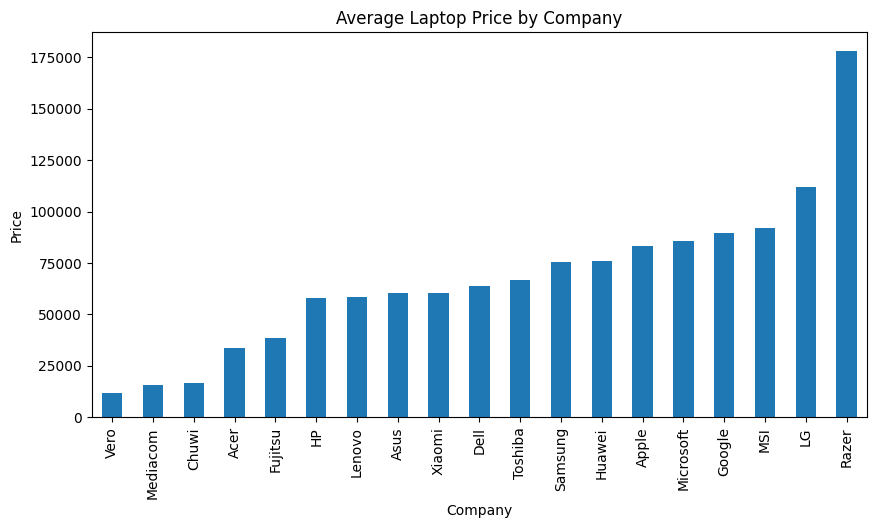

In [62]:
#average price by company
import seaborn as sns
import matplotlib.pyplot as plt

avg_price = data.groupby('Company')['Price'].mean().sort_values()

plt.figure(figsize=(10,5))
avg_price.plot(kind='bar')
plt.title('Average Laptop Price by Company')
plt.ylabel('Price')
plt.show()

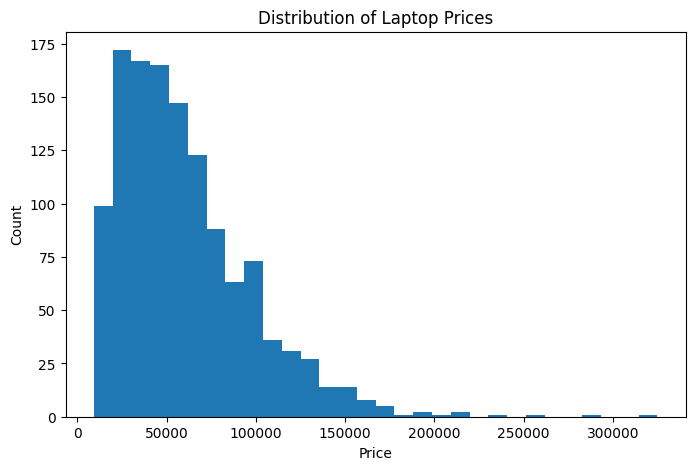

In [63]:
#distribution of laptop prices
plt.figure(figsize=(8,5))
plt.hist(data['Price'], bins=30)
plt.title('Distribution of Laptop Prices')
plt.xlabel('Price')
plt.ylabel('Count')
plt.show()

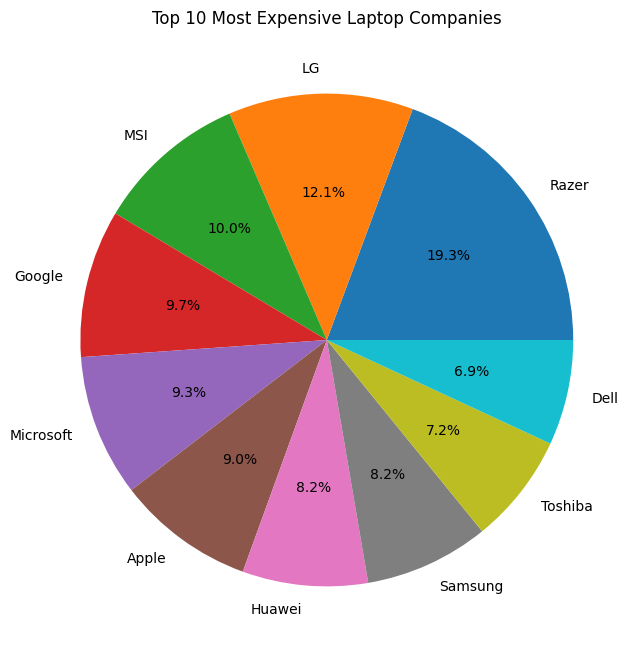

In [64]:
#top 5 most expensive laptop companies
top10 = data.groupby('Company')['Price'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,8))
plt.pie(top10, labels=top10.index, autopct='%1.1f%%')
plt.title('Top 10 Most Expensive Laptop Companies')
plt.show()

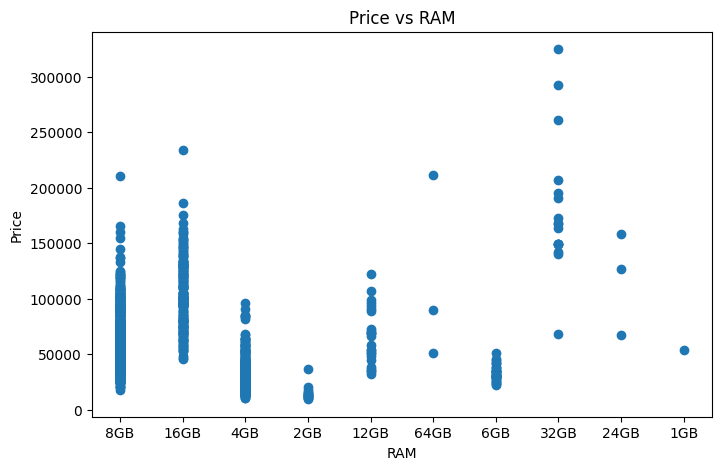

In [65]:
#Price vs RAM
plt.figure(figsize=(8,5))
plt.scatter(data['Ram'], data['Price'])
plt.xlabel('RAM')
plt.ylabel('Price')
plt.title('Price vs RAM')
plt.show()

In [66]:
#building a linear regression model to predict laptop prices
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score



# Convert categorical columns to numeric
le = LabelEncoder()

for col in data.select_dtypes(include='object').columns:
    data[col] = le.fit_transform(data[col].astype(str))

# Features and target
X = data.drop('Price', axis=1)
y = data['Price']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)


In [67]:
# Evaluating the linear regression model
print("R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R² Score: 0.4802129472318055
MAE: 18441.64121399591


In [68]:
#building a random forest regression model to predict laptop prices
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)



In [69]:
#evaluating the random forest regression model
print("R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R² Score: 0.7486903325765045
MAE: 9192.101213605505


Two machine learning models were tested for laptop price prediction: Linear Regression and Random Forest Regressor.

After evaluating both models using the R² Score, Random Forest Regressor achieved higher accuracy than Linear Regression.Therefore, Random Forest Regressor was selected as the final model for predicting laptop prices.

In [70]:
#comparison of actual vs predicted prices for the test set
comparison = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': y_pred
})

print(comparison.head(10))

      Actual Price  Predicted Price
926     87912.0000     80867.036016
1032    63499.1040     64926.860592
690     19980.0000     19502.628960
638     93635.3376     99660.240000
953     61751.5200     66257.963712
1026    63349.9200     56469.207600
768     85194.7200     89990.378208
965     24808.2336     22995.189792
463     42570.7200     75719.981556
451    105228.0000    127429.333776


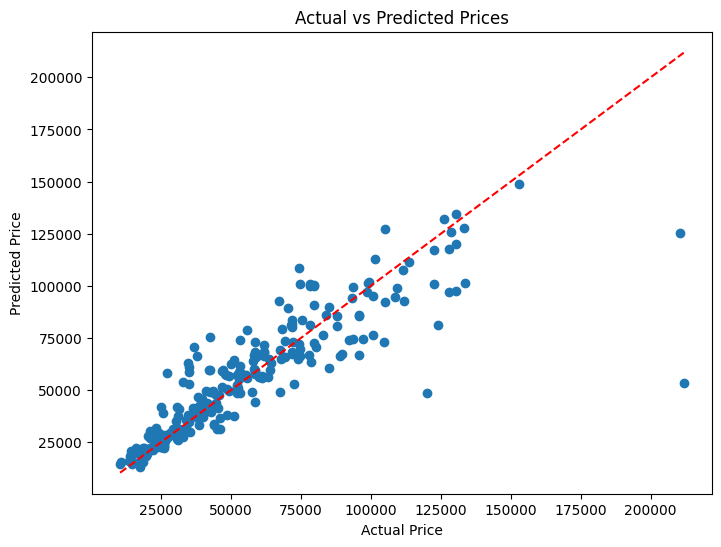

In [71]:
#visualize the actual vs predicted prices for the test set
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Prices')
plt.show()

In [76]:
#generating a new laptop data for prediction
new_laptop = pd.DataFrame({
    'Company': ['Dell'],
    'TypeName': ['Notebook'],
    'Inches': [18.6],
    'ScreenResolution': ['Full HD 1920x1080'],
    'Cpu': ['Intel Core i5'],
    'Ram': [64],
    'Memory': ['256GB SSD'],
    'Gpu': ['Intel HD Graphics'],
    'OpSys': ['Windows 11'],
    'Weight': [1.8]
})

In [77]:
new_laptop = pd.get_dummies(new_laptop)

new_laptop = new_laptop.reindex(columns=X_train.columns, fill_value=0  )

predicted_price = model.predict(new_laptop)

print("Predicted Price for the new laptop:", predicted_price[0])

Predicted Price for the new laptop: 36865.50292800007


In [74]:
#features that are most important in predicting laptop prices
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
})

print(importance.sort_values(by='Importance', ascending=False).head(10))

            Feature  Importance
5               Ram    0.396280
4               Cpu    0.237393
9            Weight    0.118881
7               Gpu    0.071883
3  ScreenResolution    0.042272
1          TypeName    0.041673
6            Memory    0.032113
0           Company    0.027418
2            Inches    0.018362
8             OpSys    0.013726


In [ ]:
#visualize the top 10 most important features affecting laptop prices
importance = importance.sort_values(
    by='Importance',
    ascending=False
).head(10)

plt.figure(figsize=(10,5))
plt.barh(importance['Feature'], importance['Importance'])
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('Top 10 Features Affecting Laptop Price')
plt.gca().invert_yaxis()
plt.show()


In [ ]:
#save the cleaned and processed dataset to a new CSV file
data.to_csv('laptop_cleaned.csv', index=False)